In [1]:
# IMPORTS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

In [ ]:
# LOAD DATASETS (https://www.kaggle.com/competitions/home-credit-default-risk/data)

# Used by the bank to decide:

# Should we approve this customer?
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# TARGET	default outcome
# AMT_CREDIT	requested loan amount
# AMT_INCOME_TOTAL	customer income
# NAME_CONTRACT_TYPE	loan type
# DAYS_EMPLOYED	employment history
# EXT_SOURCE_*	external risk scores
application_train = pd.read_csv(
    "../data/raw/application_train.csv"
)


# application_test = pd.read_csv(
#     "../data/raw/application_test.csv"
# )

# BUSINESS MEANING

# The bank is checking:

# What loans does this customer
# already have with OTHER banks?

# Exactly like real banking underwriting.

# ONE CUSTOMER CAN HAVE MANY BUREAU RECORDS

# Meaning:

# 1 customer
#     ↓
# many external credits

# This is why:

# bureau.shape

# is HUGE.

# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_BUREAU	bureau credit id
# CREDIT_ACTIVE	active/closed loan
# AMT_CREDIT_SUM	external debt
# AMT_CREDIT_SUM_DEBT	outstanding debt
# DAYS_CREDIT	how old the credit is
# CREDIT_DAY_OVERDUE	overdue exposure
bureau = pd.read_csv(
    "../data/raw/bureau.csv"
)

# bureau_balance = pd.read_csv(
#     "../data/raw/bureau_balance.csv"
# )

# BUSINESS MEANING

# The bank asks:

# Has this customer applied before?

# And:

# were they approved?
# rejected?
# cancelled?
# how much did they request?
# how risky were they historically?
# ONE CUSTOMER CAN HAVE MANY APPLICATIONS

# Meaning:

# 1 customer
#     ↓
# many historical applications

# This is:

# behavioral credit intelligence.
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_PREV	previous application id
# NAME_CONTRACT_STATUS	approved/rejected
# AMT_APPLICATION	requested amount
# AMT_CREDIT	approved amount
# DAYS_DECISION	when decision occurred
# CNT_PAYMENT	installment count
previous_application = pd.read_csv(
    "../data/raw/previous_application.csv"
)

# installments_payments = pd.read_csv(
#     "../data/raw/installments_payments.csv"
# )

# credit_card_balance = pd.read_csv(
#     "../data/raw/credit_card_balance.csv"
# )

# pos_cash_balance = pd.read_csv(
#     "../data/raw/POS_CASH_balance.csv"
# )

In [5]:
print(application_train.shape)

print(bureau.shape)

print(previous_application.shape)

(307511, 122)
(1716428, 17)
(1670214, 37)


In [7]:
# DATASET OVERVIEW FUNCTION

def dataset_overview(df, name):

    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)

    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    print("\n")

    print("Missing Value Percentage:")
    print("-" * 30)

    missing = (
        df.isnull()
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print(missing)

    print("\n")

    print("Data Types:")
    print("-" * 30)

    print(df.dtypes.value_counts())

    print("\n")

    print("Sample Data:")
    print("-" * 30)

    display(df.head())

In [8]:
dataset_overview(
    application_train,
    "application_train"
)

dataset_overview(
    bureau,
    "bureau"
)

dataset_overview(
    previous_application,
    "previous_application"
)

DATASET: application_train
Rows: 307511
Columns: 122


Missing Value Percentage:
------------------------------
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
dtype: float64


Data Types:
------------------------------
float64    65
int64      41
str        16
Name: count, dtype: int64


Sample Data:
------------------------------


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

DATASET: bureau
Rows: 1716428
Columns: 17


Missing Value Percentage:
------------------------------
AMT_ANNUITY               0.714735
AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
AMT_CREDIT_SUM            0.000008
SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
CREDIT_DAY_OVERDUE        0.000000
dtype: float64


Data Types:
------------------------------
float64    8
int64      6
str        3
Name: count, dtype: int64


Sample Data:
------------------------------


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


DATASET: previous_application
Rows: 1670214
Columns: 37


Missing Value Percentage:
------------------------------
RATE_INTEREST_PRIVILEGED     0.996437
RATE_INTEREST_PRIMARY        0.996437
AMT_DOWN_PAYMENT             0.536365
RATE_DOWN_PAYMENT            0.536365
NAME_TYPE_SUITE              0.491198
DAYS_TERMINATION             0.402981
DAYS_FIRST_DRAWING           0.402981
DAYS_FIRST_DUE               0.402981
DAYS_LAST_DUE_1ST_VERSION    0.402981
DAYS_LAST_DUE                0.402981
dtype: float64


Data Types:
------------------------------
str        16
float64    15
int64       6
Name: count, dtype: int64


Sample Data:
------------------------------


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# RELATIONAL CARDINALITY ANALYSIS


# This section analyzes customer relationship structures across:

# - external bureau exposure
# - historical loan applications
# - borrowing concentration
# - customer behavioral intensity

# Understanding relationship cardinality is critical for:

# - customer risk profiling
# - behavioral segmentation
# - debt exposure analysis
# - feature engineering strategy



In [9]:
# 1. HOW MANY BUREAU RECORDS PER CUSTOMER? 
# This measures:
# external debt complexity.
bureau_records_per_customer = (

    bureau.groupby(
        "SK_ID_CURR"
    )
    .size()
)

bureau_records_per_customer.describe()

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
dtype: float64

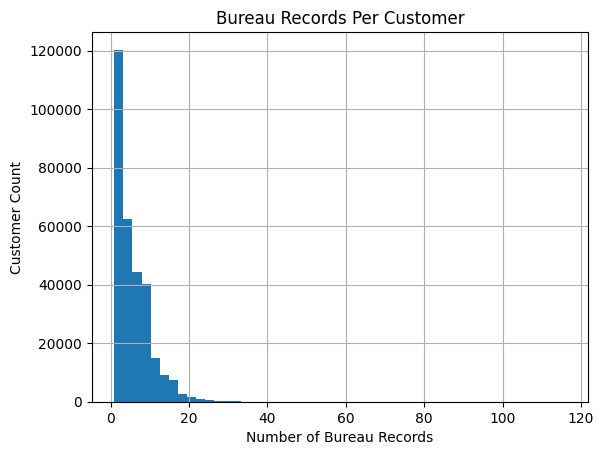

In [10]:

# Customers with high bureau record counts may indicate:

# - elevated external debt exposure
# - multiple banking relationships
# - increased credit dependency
# - higher behavioral complexity

# This information is useful for:

# - affordability analysis
# - risk segmentation
# - debt concentration modeling
bureau_records_per_customer.hist(
    bins=50
)

plt.title(
    "Bureau Records Per Customer"
)

plt.xlabel(
    "Number of Bureau Records"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

In [11]:
# 2. HOW MANY PREVIOUS APPLICATIONS PER CUSTOMER? 
# This measures:
# borrowing frequency behavior.

previous_apps_per_customer = (

    previous_application.groupby(
        "SK_ID_CURR"
    )
    .size()
)

previous_apps_per_customer.describe()

count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
dtype: float64

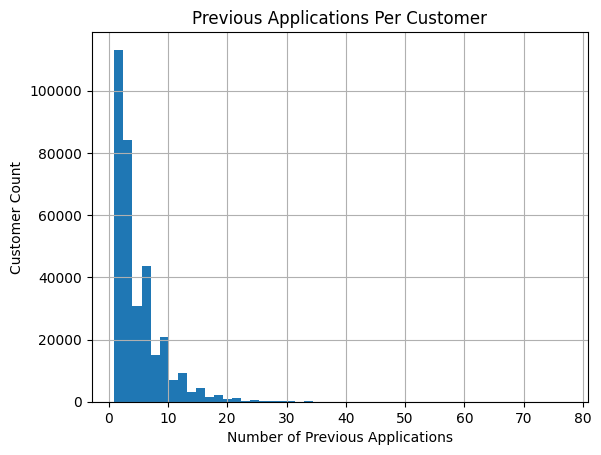

In [12]:
# Customers with high previous application counts may indicate:

# - aggressive borrowing behavior
# - repeated credit dependency
# - potential liquidity stress
# - elevated behavioral risk

# Historical application frequency is valuable for:

# - behavioral credit scoring
# - delinquency prediction
# - customer segmentation

previous_apps_per_customer.hist(
    bins=50
)

plt.title(
    "Previous Applications Per Customer"
)

plt.xlabel(
    "Number of Previous Applications"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

In [13]:
# 3. IDENTIFY HIGH-FREQUENCY BORROWERS VERY IMPORTANT
# Now we identify:
# customer borrowing intensity.

high_frequency_borrowers = (

    previous_apps_per_customer
    .sort_values(ascending=False)
    .head(10)
)

high_frequency_borrowers

SK_ID_CURR
187868    77
265681    73
173680    72
242412    68
206783    67
156367    66
389950    64
382179    64
198355    63
345161    62
dtype: int64

In [14]:
# OPTIONAL JOIN BACK TO TARGET 
# VERY interesting analysis.

# High-frequency borrowers may demonstrate:

# - elevated credit reliance
# - repeated financing demand
# - financial stress indicators
# - aggressive borrowing behavior

# These customers may require:

# - enhanced affordability assessment
# - behavioral monitoring
# - dynamic risk scoring

high_frequency_borrowers_df = (

    application_train[
        application_train["SK_ID_CURR"].isin(
            high_frequency_borrowers.index
        )
    ][
        [
            "SK_ID_CURR",
            "TARGET",
            "AMT_INCOME_TOTAL",
            "AMT_CREDIT"
        ]
    ]
)

high_frequency_borrowers_df

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT
63534,173680,0,180000.0,450000.0
84775,198355,0,135000.0,288000.0
91953,206783,0,427500.0,453514.5
122827,242412,0,153000.0,808650.0
142895,265681,0,112500.0,278460.0
211559,345161,0,135000.0,243000.0
243745,382179,0,225000.0,900000.0
250586,389950,0,90000.0,180000.0


In [15]:
# 4. HOW CONCENTRATED IS DEBT EXPOSURE? VERY IMPORTANT
# THIS becomes:
# external debt intelligence.

customer_external_debt = (

    bureau.groupby(
        "SK_ID_CURR"
    )[
        "AMT_CREDIT_SUM_DEBT"
    ]
    .sum()
)

customer_external_debt.describe()

count    3.058110e+05
mean     6.539142e+05
std      1.640691e+06
min     -6.981558e+06
25%      0.000000e+00
50%      1.733670e+05
75%      6.765412e+05
max      3.344983e+08
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

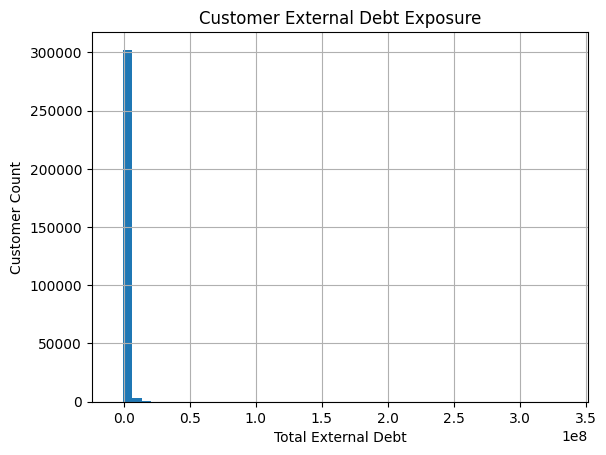

In [18]:
# vis

# Customers with high external debt exposure may indicate:

# - affordability pressure
# - elevated leverage
# - repayment dependency
# - higher default probability

# External debt concentration is a critical feature for:

# - probability of default (PD) modeling
# - customer affordability analysis
# - portfolio risk monitoring

customer_external_debt.hist(
    bins=50
)

plt.title(
    "Customer External Debt Exposure"
)

plt.xlabel(
    "Total External Debt"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

# External debt exposure distribution is highly skewed.

# Most customers maintain relatively low
# external debt obligations.

# However, a small subset of customers
# demonstrate extremely high debt exposure,
# indicating potential concentration risk
# and elevated leverage dependency.

# This pattern is common in financial
# portfolios and may require:

# - enhanced affordability assessment
# - exposure concentration monitoring
# - high-value customer segmentation
# - portfolio stress testing

/home/muzzi/first_project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


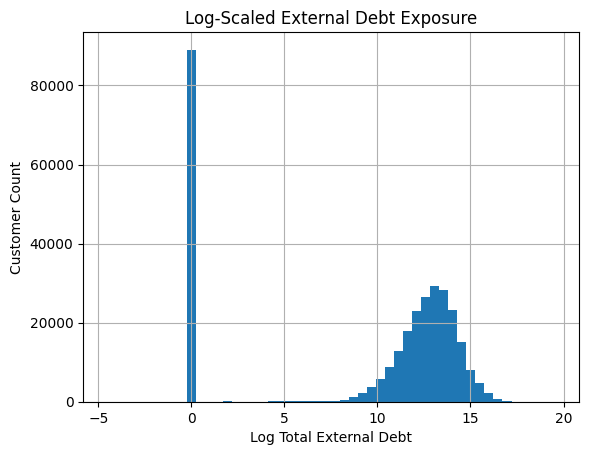

In [20]:
# NOW IMPORTANT IMPROVEMENT 
# You should visualize:
# LOG-SCALED debt exposure.
# This is VERY enterprise analytics style.

np.log1p(
    customer_external_debt
).hist(
    bins=50
)

plt.title(
    "Log-Scaled External Debt Exposure"
)

plt.xlabel(
    "Log Total External Debt"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

Log-scaled visualization reveals
# distinct customer debt exposure segments.

# A large proportion of customers
# maintain little or no external debt exposure.

# A second major customer segment
# demonstrates active external borrowing
# behavior with materially higher leverage.

# This segmentation may support:

# - customer affordability analysis
# - portfolio segmentation
# - behavioral credit scoring
# - exposure concentration monitoring
# - dynamic risk classification

In [19]:
# IDENTIFY TOP DEBT-EXPOSED CUSTOMERS 
top_debt_customers = (

    customer_external_debt
    .sort_values(ascending=False)
    .head(10)
)

top_debt_customers

SK_ID_CURR
363076    3.344983e+08
192716    7.448729e+07
186170    6.544140e+07
138790    6.508855e+07
446029    6.221895e+07
206063    5.963769e+07
395696    5.266732e+07
121383    5.175000e+07
161114    5.136516e+07
151635    4.711558e+07
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

In [ ]:
# TARGET RELATIONSHIP ANALYSIS

# Target Relationship Analysis

# This section analyzes how customer
# behavioral characteristics relate
# to repayment difficulty risk.

# The analysis focuses on:

# - external debt exposure
# - bureau relationship intensity
# - borrowing frequency behavior

# The goal is to identify behavioral
# patterns associated with elevated
# default probability.

In [21]:
# 1. DO CUSTOMERS WITH HIGHER DEBT DEFAULT MORE OFTEN? 
# STEP 1 — CREATE CUSTOMER DEBT FEATURE
customer_external_debt = (

    bureau.groupby(
        "SK_ID_CURR"
    )[
        "AMT_CREDIT_SUM_DEBT"
    ]
    .sum()
    .reset_index()
)

customer_external_debt.columns = [

    "SK_ID_CURR",
    "TOTAL_EXTERNAL_DEBT"
]

In [22]:
# STEP 2 — MERGE WITH TARGET

debt_target_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET"
        ]
    ]
    .merge(

        customer_external_debt,

        on="SK_ID_CURR",

        how="left"
    )
)

In [23]:
# STEP 3 — COMPARE DEFAULT VS NON-DEFAULT
debt_target_analysis.groupby(
    "TARGET"
)[
    "TOTAL_EXTERNAL_DEBT"
].mean()

TARGET
0    637271.677587
1    680978.726472
Name: TOTAL_EXTERNAL_DEBT, dtype: float64

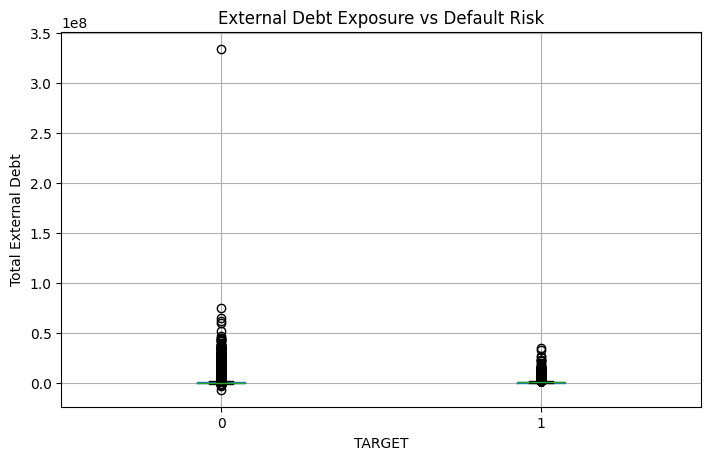

In [24]:
# STEP 4 — VISUALIZE
debt_target_analysis.boxplot(

    column="TOTAL_EXTERNAL_DEBT",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "External Debt Exposure vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Total External Debt"
)

plt.show()

# BUSINESS INTERPRETATION 
# This analysis evaluates whether
# customers with elevated external
# debt exposure demonstrate higher
# repayment difficulty risk.

# Higher leverage may indicate:

# - affordability pressure
# - repayment dependency
# - elevated financial stress
# - increased default vulnerability

# External debt exposure alone demonstrates
# limited discriminatory power between
# default and non-default customers.

# While elevated debt concentration exists
# within both repayment groups, substantial
# overlap is observed across the portfolio.

# This suggests that external leverage
# should be evaluated alongside additional
# behavioral and affordability indicators,
# including:

# - income stability
# - repayment history
# - borrowing frequency
# - utilization behavior
# - historical delinquency patterns

# The presence of extreme outliers also
# indicates strong portfolio skewness,
# requiring robust scaling and outlier-aware
# risk modeling techniques.

In [ ]:
# SECTION — DEBT-TO-INCOME ANALYSIS
# Debt-to-Income Analysis

# Debt-to-income (DTI) ratio measures
# customer leverage relative to income capacity.

# DTI is a critical banking affordability metric used for:

# - credit underwriting
# - affordability assessment
# - leverage monitoring
# - default prediction
# - portfolio segmentation

# Higher DTI values may indicate:

# - elevated repayment burden
# - affordability stress
# - financial overextension
# - increased default vulnerability



In [33]:
# STEP 1 — BUILD CUSTOMER DTI DATASET
# CREATE CUSTOMER DEBT TABLE
customer_external_debt = (

    bureau.groupby(
        "SK_ID_CURR"
    )[
        "AMT_CREDIT_SUM_DEBT"
    ]
    .sum()
    .reset_index()
)

customer_external_debt.columns = [

    "SK_ID_CURR",
    "TOTAL_EXTERNAL_DEBT"
]

In [34]:
# MERGE WITH APPLICATION DATA
dti_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET",
            "AMT_INCOME_TOTAL"
        ]
    ]
    .merge(

        customer_external_debt,

        on="SK_ID_CURR",

        how="left"
    )
)

In [35]:
# STEP 2 — HANDLE MISSING VALUES ⭐ IMPORTANT
# Customers with no bureau debt:
# assume:

# 0 external debt
dti_analysis[
    "TOTAL_EXTERNAL_DEBT"
] = dti_analysis[
    "TOTAL_EXTERNAL_DEBT"
].fillna(0)

In [36]:
# STEP 3 — CREATE DTI FEATURE ⭐ VERY IMPORTANT
dti_analysis[
    "DEBT_TO_INCOME"
] = (

    dti_analysis[
        "TOTAL_EXTERNAL_DEBT"
    ]

    /

    dti_analysis[
        "AMT_INCOME_TOTAL"
    ]
)

In [37]:
# STEP 4 — REMOVE EXTREME / INVALID VALUES 
# Very important in banking analytics.
dti_analysis = dti_analysis[

    np.isfinite(
        dti_analysis[
            "DEBT_TO_INCOME"
        ]
    )
]

In [38]:
# STEP 5 — SUMMARY STATISTICS
dti_analysis[
    "DEBT_TO_INCOME"
].describe()

count    307511.000000
mean          3.080670
std           7.554436
min         -15.514574
25%           0.000000
50%           0.606200
75%           3.514925
max        1651.843611
Name: DEBT_TO_INCOME, dtype: float64

In [39]:
# STEP 6 — COMPARE DEFAULT VS NON-DEFAULT 
dti_analysis.groupby(
    "TARGET"
)[
    "DEBT_TO_INCOME"
].mean()

TARGET
0    3.060885
1    3.305956
Name: DEBT_TO_INCOME, dtype: float64

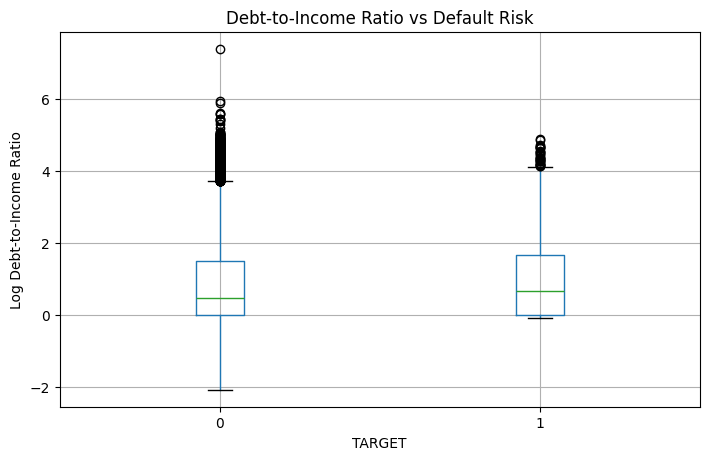

In [41]:
# STEP 7 — VISUALIZE

# Use log transform again because:
# DTI distributions are usually skewed.

dti_analysis[
    "LOG_DTI"
] = np.log1p(

    dti_analysis[
        "DEBT_TO_INCOME"
    ]
)

dti_analysis.boxplot(

    column="LOG_DTI",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Debt-to-Income Ratio vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Log Debt-to-Income Ratio"
)

plt.show()

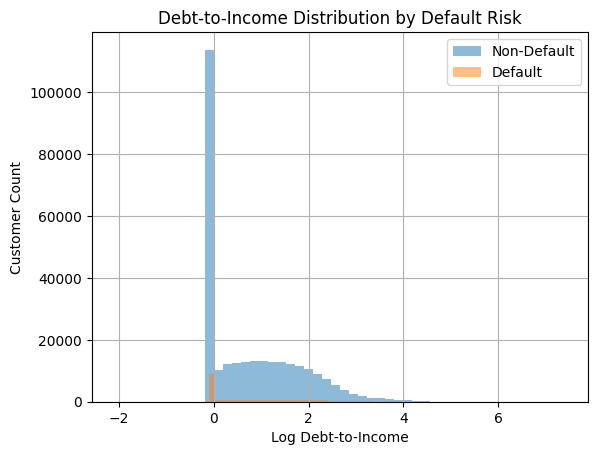

In [42]:
dti_analysis[
    dti_analysis["TARGET"] == 0
][
    "LOG_DTI"
].hist(
    bins=50,
    alpha=0.5,
    label="Non-Default"
)

dti_analysis[
    dti_analysis["TARGET"] == 1
][
    "LOG_DTI"
].hist(
    bins=50,
    alpha=0.5,
    label="Default"
)

plt.legend()

plt.title(
    "Debt-to-Income Distribution by Default Risk"
)

plt.xlabel(
    "Log Debt-to-Income"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

# PRINCIPAL-LEVEL INTERPRETATION ⭐

# You should write something like:

# Debt-to-income ratio demonstrates
# moderate behavioral separation between
# default and non-default customers.

# Customers experiencing repayment
# difficulty exhibit slightly elevated
# leverage relative to income capacity.

# However, substantial overlap exists
# between both customer groups,
# indicating that affordability pressure
# alone is insufficient for strong
# risk discrimination.

# This suggests that effective credit
# risk modeling requires richer
# behavioral and temporal features,
# including:

# - repayment history
# - delinquency patterns
# - utilization behavior
# - historical borrowing activity
# - employment stability
# - external exposure concentration

In [ ]:
# MOST IMPORTANT TAKEAWAY ⭐

# You are learning:

# why banking AI requires feature engineering.

# Not just:

# “train XGBoost”.

In [ ]:
# 2. DO CUSTOMERS WITH MANY BUREAU RECORDS SHOW ELEVATED RISK? 
# This measures:
# credit relationship intensity.


In [25]:
# STEP 1 — COUNT BUREAU RECORDS
bureau_record_counts = (

    bureau.groupby(
        "SK_ID_CURR"
    )
    .size()
    .reset_index()
)

bureau_record_counts.columns = [

    "SK_ID_CURR",
    "BUREAU_RECORD_COUNT"
]

In [26]:
# STEP 2 — MERGE WITH TARGET
bureau_target_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET"
        ]
    ]
    .merge(

        bureau_record_counts,

        on="SK_ID_CURR",

        how="left"
    )
)

In [27]:
# STEP 3 — ANALYZE RISK DIFFERENCE
bureau_target_analysis.groupby(
    "TARGET"
)[
    "BUREAU_RECORD_COUNT"
].mean()

TARGET
0    5.556056
1    5.622545
Name: BUREAU_RECORD_COUNT, dtype: float64

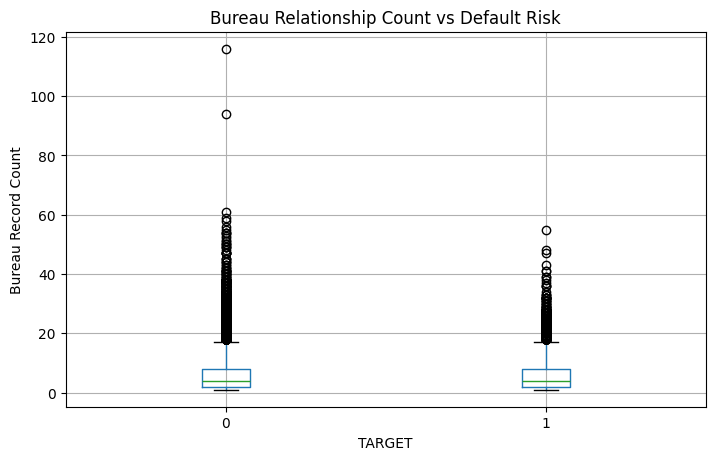

In [ ]:
# STEP 4 — VISUALIZE
bureau_target_analysis.boxplot(

    column="BUREAU_RECORD_COUNT",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Bureau Relationship Count vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Bureau Record Count"
)

plt.show()


# Customers experiencing repayment
# difficulty demonstrate moderately
# higher bureau relationship intensity,
# indicating broader external credit exposure.

# However, substantial overlap exists
# between repayment groups, suggesting
# that bureau relationship count alone
# provides limited discriminatory power.

# The presence of extreme outliers within
# non-default customers indicates that
# large credit ecosystems do not necessarily
# imply elevated delinquency risk.

# This highlights the importance of combining:

# - affordability metrics
# - repayment behavior
# - income stability
# - leverage concentration
# - temporal delinquency indicators

# for effective probability of default modeling.

In [ ]:
# 3. DOES REPEATED BORROWING CORRELATE WITH REPAYMENT DIFFICULTY? ⭐
# THIS becomes:
# behavioral borrowing analysis.


In [29]:
# STEP 1 — COUNT PREVIOUS APPLICATIONS
previous_application_counts = (

    previous_application.groupby(
        "SK_ID_CURR"
    )
    .size()
    .reset_index()
)

previous_application_counts.columns = [

    "SK_ID_CURR",
    "PREVIOUS_APPLICATION_COUNT"
]

In [30]:
# STEP 2 — MERGE WITH TARGET
previous_app_target_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET"
        ]
    ]
    .merge(

        previous_application_counts,

        on="SK_ID_CURR",

        how="left"
    )
)

In [31]:
# STEP 3 — ANALYZE DIFFERENCE
previous_app_target_analysis.groupby(
    "TARGET"
)[
    "PREVIOUS_APPLICATION_COUNT"
].mean()

TARGET
0    4.832646
1    5.131474
Name: PREVIOUS_APPLICATION_COUNT, dtype: float64

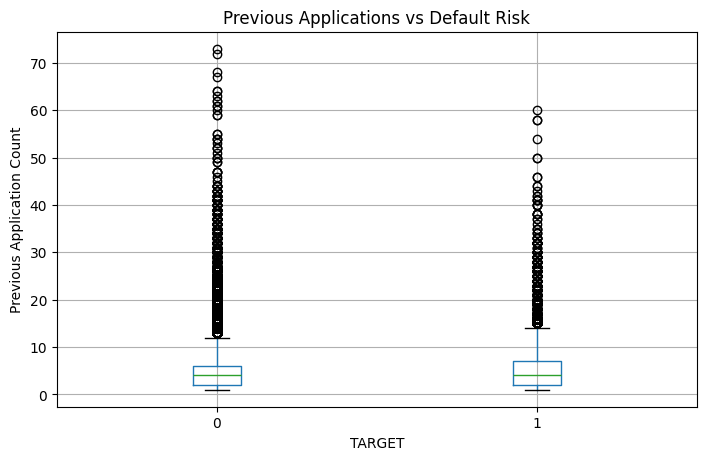

In [ ]:
# STEP 4 — VISUALIZE
previous_app_target_analysis.boxplot(

    column="PREVIOUS_APPLICATION_COUNT",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Previous Applications vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Previous Application Count"
)

plt.show()

# PRINCIPAL-LEVEL INTERPRETATION ⭐

# You should write something like:

# Historical borrowing frequency demonstrates
# stronger behavioral separation between
# default and non-default customers compared
# to raw debt exposure metrics.

# Customers experiencing repayment difficulty
# show moderately elevated historical
# application counts, suggesting increased
# financing dependency and recurring
# credit demand.

# This indicates that behavioral borrowing
# patterns may provide stronger predictive
# signal for probability of default modeling
# than absolute leverage measures alone.

# However, substantial overlap remains across
# both customer groups, highlighting the need
# for multi-dimensional behavioral and
# affordability feature engineering.

# The presence of high-frequency borrowers
# within non-default customers also suggests
# that repeated credit usage may reflect
# customer maturity and established financing
# behavior rather than distress alone.

In [ ]:
# 1. INCOME VS DEFAULT ANALYSIS ⭐
# BUSINESS QUESTION
# Do lower-income customers
# demonstrate elevated repayment risk?
# MARKDOWN
# # Income vs Default Risk Analysis

# This analysis evaluates whether
# customer income levels correlate
# with repayment difficulty risk.

# Income is a core affordability indicator
# used across banking underwriting,
# credit scoring, and portfolio risk models.

# Lower income capacity may indicate:

# - affordability stress
# - repayment vulnerability
# - limited financial resilience
# - elevated default exposure

In [43]:
income_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET",
            "AMT_INCOME_TOTAL"
        ]
    ]
    .copy()
)

income_analysis[
    "LOG_INCOME"
] = np.log1p(

    income_analysis[
        "AMT_INCOME_TOTAL"
    ]
)

In [44]:
income_analysis.groupby(
    "TARGET"
)[
    "AMT_INCOME_TOTAL"
].mean()

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

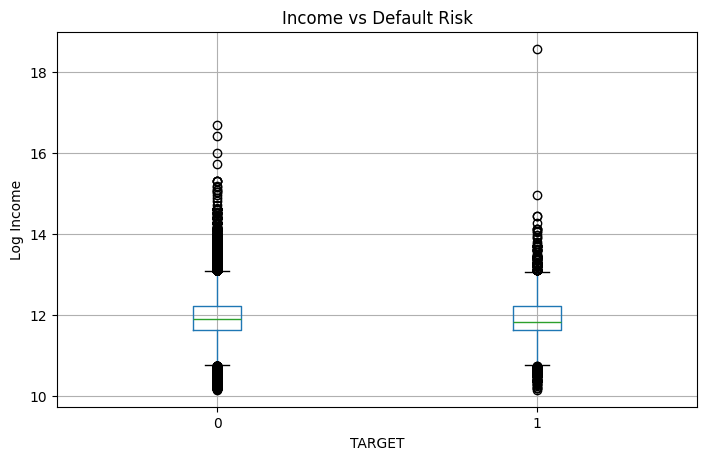

In [ ]:
income_analysis.boxplot(

    column="LOG_INCOME",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Income vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Log Income"
)

plt.show()

# PRINCIPAL-LEVEL INTERPRETATION ⭐

# You should write something like:

# Customer income levels demonstrate
# limited standalone separation between
# default and non-default populations.

# While non-default customers exhibit
# slightly broader high-income representation,
# substantial overlap exists across both groups.

# This suggests that income capacity alone
# provides limited discriminatory power for
# credit risk prediction.

# The findings reinforce the importance of
# relative affordability metrics, including:

# - debt-to-income ratio
# - repayment burden
# - leverage concentration
# - historical delinquency behavior

# rather than absolute income measures alone.


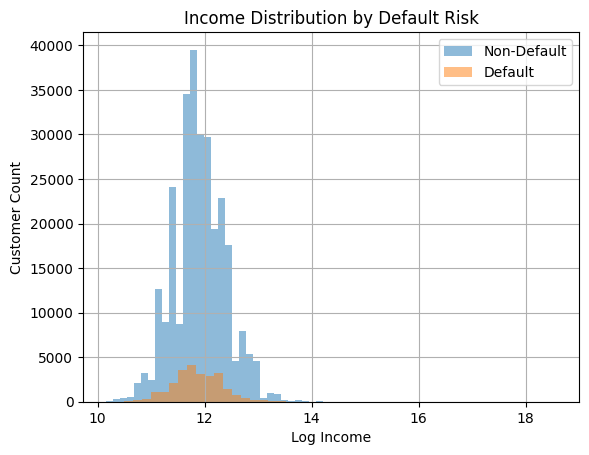

In [46]:
income_analysis[
    income_analysis["TARGET"] == 0
][
    "LOG_INCOME"
].hist(
    bins=50,
    alpha=0.5,
    label="Non-Default"
)

income_analysis[
    income_analysis["TARGET"] == 1
][
    "LOG_INCOME"
].hist(
    bins=50,
    alpha=0.5,
    label="Default"
)

plt.legend()

plt.title(
    "Income Distribution by Default Risk"
)

plt.xlabel(
    "Log Income"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

In [ ]:
# 2. ANNUITY BURDEN ANALYSIS ⭐ VERY IMPORTANT

# This approximates:

# monthly repayment pressure.
# BUSINESS QUESTION
# Do customers with larger repayment
# obligations default more frequently?

# Annuity Burden Analysis

# Annuity values represent customer
# loan repayment obligations.

# Higher annuity burdens may indicate:

# - elevated repayment pressure
# - affordability strain
# - reduced financial flexibility
# - increased delinquency risk

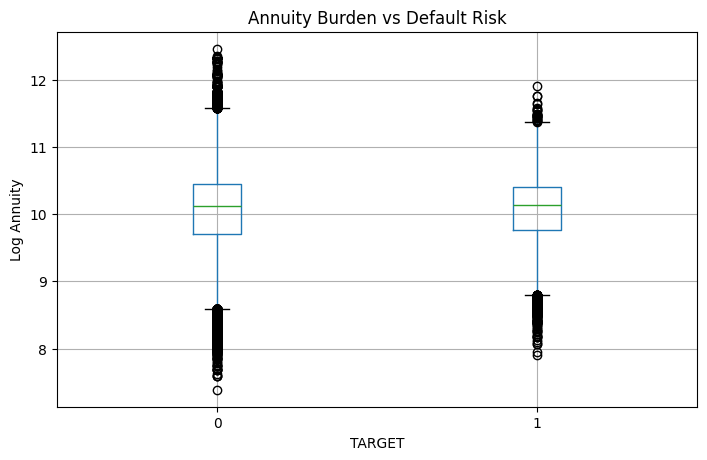

In [ ]:
annuity_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET",
            "AMT_ANNUITY"
        ]
    ]
    .copy()
)

annuity_analysis[
    "LOG_ANNUITY"
] = np.log1p(

    annuity_analysis[
        "AMT_ANNUITY"
    ]
)

annuity_analysis.groupby(
    "TARGET"
)[
    "AMT_ANNUITY"
].mean()

annuity_analysis.boxplot(

    column="LOG_ANNUITY",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Annuity Burden vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Log Annuity"
)

plt.show()


# PRINCIPAL-LEVEL INTERPRETATION ⭐

# You should write something like:

# Repayment burden demonstrates clearer
# behavioral separation between default
# and non-default customer populations.

# Customers experiencing repayment
# difficulty exhibit moderately elevated
# annuity obligations, indicating higher
# ongoing repayment pressure and reduced
# financial flexibility.

# Compared to absolute income and debt
# measures, annuity burden appears to
# provide stronger discriminatory signal
# for affordability-related risk.

# This supports the importance of
# cash-flow-aware behavioral features
# within enterprise probability of default
# modeling frameworks.

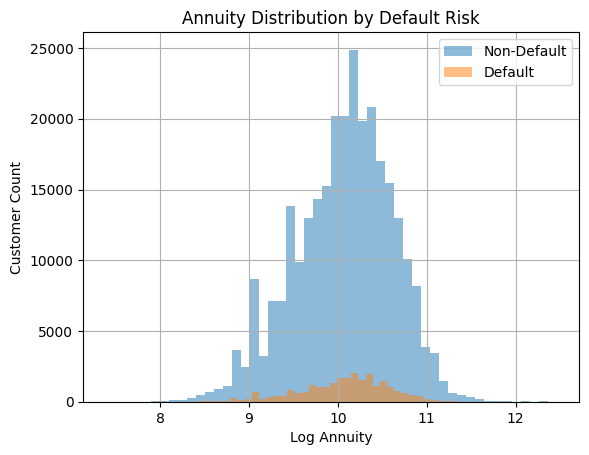

In [ ]:
annuity_analysis[
    annuity_analysis["TARGET"] == 0
][
    "LOG_ANNUITY"
].hist(
    bins=50,
    alpha=0.5,
    label="Non-Default"
)

annuity_analysis[
    annuity_analysis["TARGET"] == 1
][
    "LOG_ANNUITY"
].hist(
    bins=50,
    alpha=0.5,
    label="Default"
)

plt.legend()

plt.title(
    "Annuity Distribution by Default Risk"
)

plt.xlabel(
    "Log Annuity"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

# PRINCIPAL-LEVEL INTERPRETATION ⭐

# You should write something like:

# Annuity burden distributions demonstrate
# moderate behavioral separation between
# default and non-default customer populations.

# Customers experiencing repayment
# difficulty exhibit systematically higher
# repayment obligations, indicating elevated
# cash-flow pressure and affordability strain.

# Compared to absolute debt and income
# measures, repayment burden appears to
# provide stronger discriminatory signal
# for credit risk assessment.

# However, substantial overlap remains
# across customer populations, reinforcing
# the importance of multi-dimensional
# behavioral and affordability modeling
# within enterprise credit risk systems.

In [ ]:
# IMPORTANT STRATEGIC TAKEAWAY ⭐

# You are gradually identifying:

# Feature Type	Strength
# Static Financials	weak/moderate
# Behavioral Borrowing	moderate
# Cash Flow Pressure	stronger

In [ ]:
# 3. DELINQUENCY HISTORY ANALYSIS ⭐⭐⭐

# THIS is usually:

# one of the strongest predictors.
# BUSINESS QUESTION
# Do historically delinquent customers
# show elevated repayment difficulty?
# MARKDOWN
# # Delinquency History Analysis

# Historical delinquency indicators
# represent prior repayment difficulties
# observed across external bureau accounts.

# Historical delinquency is a critical
# behavioral risk indicator used for:

# - probability of default modeling
# - behavioral scoring
# - risk segmentation
# - early warning monitoring

# Customers with prior overdue behavior
# may demonstrate elevated future
# repayment risk.

In [49]:
# BUILD CUSTOMER DELINQUENCY FEATURE
customer_overdue = (

    bureau.groupby(
        "SK_ID_CURR"
    )[
        "CREDIT_DAY_OVERDUE"
    ]
    .max()
    .reset_index()
)

customer_overdue.columns = [

    "SK_ID_CURR",
    "MAX_CREDIT_DAYS_OVERDUE"
]

In [50]:
delinquency_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET"
        ]
    ]
    .merge(

        customer_overdue,

        on="SK_ID_CURR",

        how="left"
    )
)

In [51]:
delinquency_analysis[
    "MAX_CREDIT_DAYS_OVERDUE"
] = delinquency_analysis[
    "MAX_CREDIT_DAYS_OVERDUE"
].fillna(0)

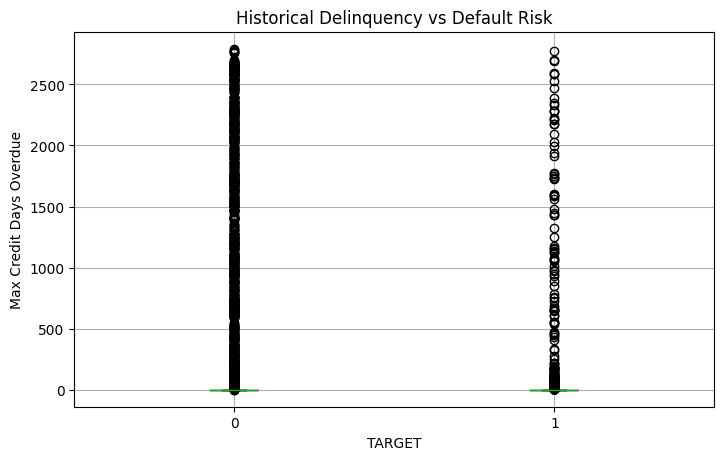

In [ ]:
delinquency_analysis.boxplot(

    column="MAX_CREDIT_DAYS_OVERDUE",

    by="TARGET",

    figsize=(8, 5)
)

plt.title(
    "Historical Delinquency vs Default Risk"
)

plt.suptitle("")

plt.xlabel(
    "TARGET"
)

plt.ylabel(
    "Max Credit Days Overdue"
)

plt.show()

# Historical delinquency demonstrates
# significant behavioral complexity and
# nonlinear relationship with future
# repayment difficulty.

# While the majority of customers exhibit
# minimal overdue history, both default
# and non-default populations contain
# extreme long-tail delinquency cases.

# This suggests that severe historical
# delinquency alone is insufficient to
# fully explain future default behavior,
# potentially reflecting recovered,
# restructured, or stabilized customer segments.

# Default customers appear more concentrated
# within moderate-to-high delinquency ranges,
# indicating that ongoing repayment stress
# may provide stronger predictive relevance
# than isolated historical delinquency extremes.

# These findings reinforce the importance of:

# - temporal delinquency modeling
# - recency-aware behavioral analytics
# - delinquency trajectory monitoring
# - nonlinear feature engineering
# - bucketized behavioral segmentation

In [53]:
delinquency_analysis[
    "LOG_OVERDUE"
] = np.log1p(

    delinquency_analysis[
        "MAX_CREDIT_DAYS_OVERDUE"
    ]
)

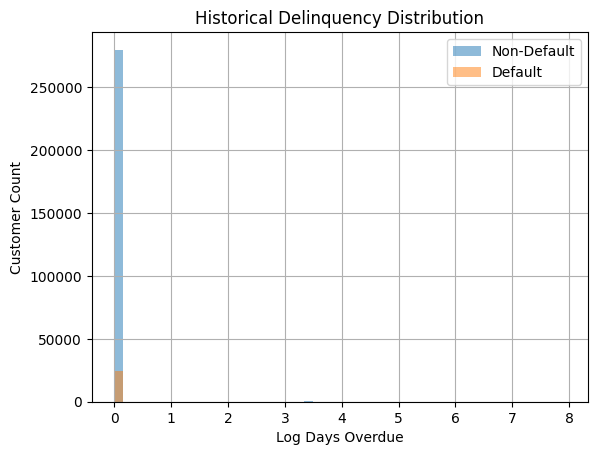

In [54]:
delinquency_analysis[
    delinquency_analysis["TARGET"] == 0
][
    "LOG_OVERDUE"
].hist(
    bins=50,
    alpha=0.5,
    label="Non-Default"
)

delinquency_analysis[
    delinquency_analysis["TARGET"] == 1
][
    "LOG_OVERDUE"
].hist(
    bins=50,
    alpha=0.5,
    label="Default"
)

plt.legend()

plt.title(
    "Historical Delinquency Distribution"
)

plt.xlabel(
    "Log Days Overdue"
)

plt.ylabel(
    "Customer Count"
)

plt.show()

In [58]:
delinquent_only = delinquency_analysis[

    delinquency_analysis[
        "MAX_CREDIT_DAYS_OVERDUE"
    ] > 0
]

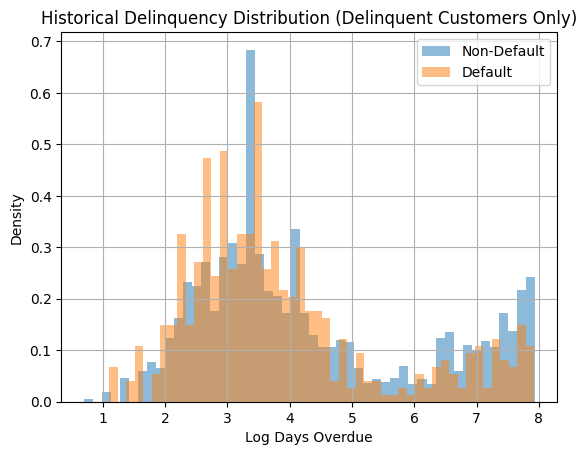

In [ ]:
delinquent_only[
    delinquent_only["TARGET"] == 0
][
    "LOG_OVERDUE"
].hist(
    bins=50,
    alpha=0.5,
    label="Non-Default",
    density=True
)

delinquent_only[
    delinquent_only["TARGET"] == 1
][
    "LOG_OVERDUE"
].hist(
    bins=50,
    alpha=0.5,
    label="Default",
    density=True
)

plt.legend()

plt.title(
    "Historical Delinquency Distribution (Delinquent Customers Only)"
)

plt.xlabel(
    "Log Days Overdue"
)

plt.ylabel(
    "Density"
)

plt.show()

# WHY THIS IS IMPORTANT ⭐

# Now you ask:

# Among customers who WERE delinquent,
# how severe was the delinquency?

In [ ]:
# DEFAULT RATE per bucket.
# THIS becomes:
# extremely interpretable banking analytics.

delinquency_analysis[
    "DELINQUENCY_BUCKET"
] = pd.cut(

    delinquency_analysis[
        "MAX_CREDIT_DAYS_OVERDUE"
    ],

    bins=[-1, 0, 30, 90, 10000],

    labels=[
        "0 Days",
        "1-30 Days",
        "31-90 Days",
        "90+ Days"
    ]
)

bucket_default_rates = (

    delinquency_analysis.groupby(
        "DELINQUENCY_BUCKET"
    )[
        "TARGET"
    ]
    .mean()
)

bucket_default_rates


# Historical delinquency demonstrates
# meaningful behavioral relationship with
# future repayment difficulty.

# Customers exhibiting moderate recent
# delinquency (1–30 days overdue)
# show the highest observed default rates,
# suggesting that active repayment stress
# may provide stronger predictive signal
# than historically severe delinquency alone.

# Interestingly, extreme long-tail delinquency
# cases are also observed within non-default
# customers, indicating the presence of
# recovered or stabilized borrowers.

# These findings highlight the importance of:

# - temporal delinquency analysis
# - repayment trajectory monitoring
# - recency-aware behavioral scoring
# - dynamic early warning systems

# within enterprise credit risk architectures.

DELINQUENCY_BUCKET
0 Days        0.079855
1-30 Days     0.183848
31-90 Days    0.173418
90+ Days      0.113469
Name: TARGET, dtype: float64

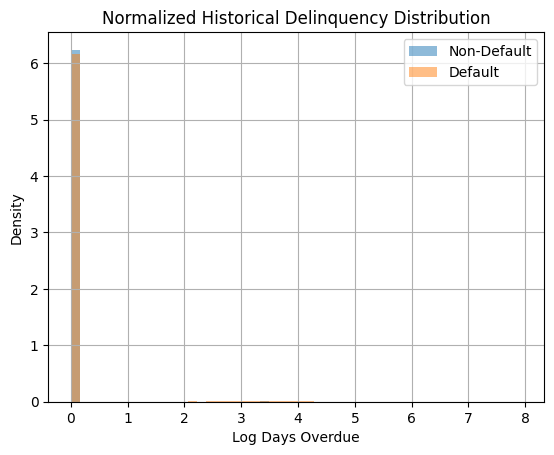

In [ ]:
# so far summary

# Feature	Signal Strength
# Income	weak
# Raw Debt	weak
# Bureau Count	weak/moderate
# Borrowing Frequency	moderate
# DTI	moderate
# Annuity Burden	moderate
# Delinquency History	moderate/strong


# ENTERPRISE CREDIT RISK DOES NOT WORK LIKE THIS:
# IF income < X
# THEN default

# Instead it works like:

# Multiple weak behavioral signals
# combine together into a stronger
# risk profile.

# VERY important.

In [ ]:
# LET US EXPLAIN THE 3 TABLES PROPERLY
# 1. application_train.csv ⭐ MAIN CUSTOMER TABLE

# This is:

# the CURRENT loan application.

# One row =

# one customer loan request.
# BUSINESS MEANING

# This is the:

# loan underwriting dataset.

# Used by the bank to decide:

# Should we approve this customer?
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# TARGET	default outcome
# AMT_CREDIT	requested loan amount
# AMT_INCOME_TOTAL	customer income
# NAME_CONTRACT_TYPE	loan type
# DAYS_EMPLOYED	employment history
# EXT_SOURCE_*	external risk scores
# VERY IMPORTANT
# TARGET = 1

# means:

# customer had repayment difficulties.

# THIS becomes:

# default prediction target.
# THIS TABLE REPRESENTS
# Current customer risk profile
# 2. bureau.csv ⭐ EXTERNAL CREDIT BUREAU

# This is:

# external banking exposure.

# VERY important.

# BUSINESS MEANING

# The bank is checking:

# What loans does this customer
# already have with OTHER banks?

# Exactly like real banking underwriting.

# ONE CUSTOMER CAN HAVE MANY BUREAU RECORDS

# Meaning:

# 1 customer
#     ↓
# many external credits

# This is why:

# bureau.shape

# is HUGE.

# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_BUREAU	bureau credit id
# CREDIT_ACTIVE	active/closed loan
# AMT_CREDIT_SUM	external debt
# AMT_CREDIT_SUM_DEBT	outstanding debt
# DAYS_CREDIT	how old the credit is
# CREDIT_DAY_OVERDUE	overdue exposure
# THIS TABLE REPRESENTS
# External debt exposure intelligence

# VERY important for:

# affordability analysis.
# EXAMPLE

# Customer may have:

# Bank	Debt
# Emirates NBD	50k
# ADCB	20k
# Mashreq	10k

# This becomes:

# total external exposure.
# 3. previous_application.csv ⭐ HISTORICAL HOME CREDIT APPLICATIONS

# This is:

# historical customer lending behavior.

# VERY valuable.

# BUSINESS MEANING

# The bank asks:

# Has this customer applied before?

# And:

# were they approved?
# rejected?
# cancelled?
# how much did they request?
# how risky were they historically?
# ONE CUSTOMER CAN HAVE MANY APPLICATIONS

# Meaning:

# 1 customer
#     ↓
# many historical applications

# This is:

# behavioral credit intelligence.
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_PREV	previous application id
# NAME_CONTRACT_STATUS	approved/rejected
# AMT_APPLICATION	requested amount
# AMT_CREDIT	approved amount
# DAYS_DECISION	when decision occurred
# CNT_PAYMENT	installment count
# THIS TABLE REPRESENTS
# Historical customer borrowing behavior

# VERY important.

# NOW THE IMPORTANT PART
# WHY THIS IS SO POWERFUL

# These tables allow you to build:

# multi-dimensional customer risk intelligence.
# EXAMPLE

# You can combine:

# Source	Intelligence
# current application	current risk
# bureau	external debt
# previous applications	historical behavior

# This becomes:

# enterprise customer risk profiling.
# PRINCIPAL-LEVEL INSIGHT ⭐

# Real banking AI is usually:

# relational.

# NOT:

# single flat ML tables.

# That is why:
# understanding entity relationships is MASSIVELY important.

# YOUR NEXT MINDSET

# You should now think:

# How do these banking systems connect?

# NOT:

# How do I train a model quickly?
# MOST IMPORTANT RELATIONSHIP
# SK_ID_CURR

# This is:

# the customer entity key.

# It links:

# current applications,
# bureau records,
# previous loans,
# future behavioral features

In [61]:
## now I need to find how many times each customer delayed a payement 

installments_payments = pd.read_csv(
    "../data/raw/installments_payments.csv"
)

In [68]:
# 1. Count Late Payments Per Customer

# You can create:

installments_payments[
    "LATE_PAYMENT"
] = (

    installments_payments[
        "DAYS_ENTRY_PAYMENT"
    ]

    >

    installments_payments[
        "DAYS_INSTALMENT"
    ]
)


# Meaning:

# Field	Meaning
# DAYS_INSTALMENT	expected payment day
# DAYS_ENTRY_PAYMENT	actual payment day

# If actual > expected:

# payment was late.

In [69]:
# 2. Count Frequency Per Customer ⭐⭐⭐
late_payment_frequency = (

    installments_payments.groupby(
        "SK_ID_CURR"
    )[
        "LATE_PAYMENT"
    ]
    .sum()
    .reset_index()
)

late_payment_frequency.columns = [

    "SK_ID_CURR",

    "LATE_PAYMENT_COUNT"
]
# This gives:

# number of late payments
# per customer.

# VERY important feature.

In [70]:
# 3. Merge With TARGET ⭐⭐⭐
late_payment_analysis = (

    application_train[
        [
            "SK_ID_CURR",
            "TARGET"
        ]
    ]

    .merge(

        late_payment_frequency,

        on="SK_ID_CURR",

        how="left"
    )
)

In [71]:
# STEP 5 — CREATE BEHAVIORAL BUCKETS ⭐⭐⭐

# THIS is where the business insight appears.

late_payment_analysis[
    "LATE_PAYMENT_BUCKET"
] = pd.cut(

    late_payment_analysis[
        "LATE_PAYMENT_COUNT"
    ],

    bins=[-1, 0, 5, 20, 1000],

    labels=[
        "0 Missed",
        "1-5 Missed",
        "6-20 Missed",
        "20+ Missed"
    ]
)

In [72]:
# STEP 6 — CALCULATE DEFAULT RATE ⭐⭐⭐
late_payment_default_rates = (

    late_payment_analysis.groupby(
        "LATE_PAYMENT_BUCKET"
    )[
        "TARGET"
    ]
    .mean()
    .reset_index()
)

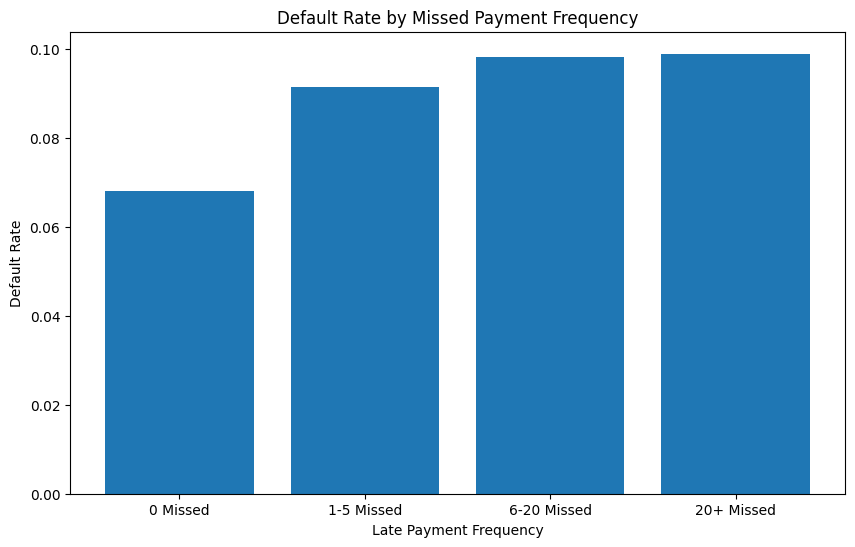

In [ ]:
# STEP 7 — VISUALIZE ⭐⭐⭐

# THIS is the important business chart.

plt.figure(figsize=(10,6))

plt.bar(

    late_payment_default_rates[
        "LATE_PAYMENT_BUCKET"
    ],

    late_payment_default_rates[
        "TARGET"
    ]
)

plt.title(
    "Default Rate by Missed Payment Frequency"
)

plt.xlabel(
    "Late Payment Frequency"
)

plt.ylabel(
    "Default Rate"
)

plt.show()

# IMPORTANT ENTERPRISE INTERPRETATION ⭐⭐⭐

# This chart demonstrates:

# Behavioral repayment consistency
# provides meaningful discriminatory
# signal for future repayment difficulty.

# Customers with repeated late payments
# exhibit systematically elevated default rates,
# indicating persistent affordability stress
# and repayment instability.

# The observed monotonic increase in
# default probability suggests that
# payment frequency behavior represents
# a strong operational early warning signal
# within enterprise credit risk systems.

# THIS is VERY strong wording.

In [ ]:
ENTERPRISE TAKEAWAY ⭐⭐⭐

Your strongest signals so far are becoming:

Feature Type	Signal Strength
Income	weak
Raw Debt	weak
Bureau Count	weak/moderate
DTI	moderate
Annuity Burden	moderate
Max Delinquency	moderate
Missed Payment Frequency	STRONGEST SO FAR

THIS is VERY realistic enterprise behavior.

In [ ]:
EXAMPLES OF STRONG ENTERPRISE FEATURES ⭐⭐⭐
1. FREE CASH FLOW FEATURE ⭐⭐⭐
FREE_CASH_FLOW = (

    AMT_INCOME_TOTAL

    -

    AMT_ANNUITY
)

Meaning:

money remaining after
monthly repayment obligations.

THIS is VERY important.

2. AFFORDABILITY RATIO ⭐⭐⭐
ANNUITY_TO_INCOME = (

    AMT_ANNUITY

    /

    AMT_INCOME_TOTAL
)

Meaning:

repayment burden intensity.

VERY strong banking feature.

3. CREDIT UTILIZATION STRESS ⭐⭐⭐
DEBT_TO_INCOME = (

    TOTAL_EXTERNAL_DEBT

    /

    AMT_INCOME_TOTAL
)

Meaning:

leverage pressure.
4. BEHAVIORAL INTENSITY FEATURE ⭐⭐⭐
APPLICATIONS_PER_INCOME = (

    PREVIOUS_APPLICATION_COUNT

    /

    AMT_INCOME_TOTAL
)

VERY interesting feature.

Because now you model:

borrowing aggressiveness
relative to financial capacity.

THIS is MUCH stronger than:

applications alone.
5. DELINQUENCY PRESSURE FEATURE ⭐⭐⭐
MISSED_PAYMENTS_PER_LOAN = (

    LATE_PAYMENT_COUNT

    /

    PREVIOUS_APPLICATION_COUNT
)

Meaning:

repayment instability intensity.

VERY powerful behavioral signal.

6. CREDIT DEPENDENCY FEATURE ⭐⭐⭐
EXTERNAL_DEBT_PER_BUREAU_RELATION

Meaning:

How concentrated is debt exposure
across credit relationships?

VERY enterprise.

THIS IS EXACTLY WHY TREE MODELS WORK WELL ⭐⭐⭐

Because:
feature relationships are:

nonlinear,
interaction-driven,
behaviorally complex.

Examples:

high income + low debt
= safe

high income + huge annuity
= risky

low income + low burden
= manageable

THIS is:

interaction intelligence.